# Week 05: FFT & STFT

**Milestone 2 – Filtering**

## Objectives
- Use FFT to analyze signal spectra
- Compare DFT vs FFT efficiency
- Apply STFT for time-varying signals
- Create FFT-based spectrum analyzer

## Part 1: Understanding DFT vs FFT

The Discrete Fourier Transform (DFT) transforms a signal from the time domain to the frequency domain.
However, the DFT is computationally expensive, especially for large signals. Fast Fourier Transform (FFT) is a faster implementation.

- DFT Complexity: \( O(N^2) \)
- FFT Complexity: \( O(N \log N) \)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from time import time

N = 2048
x = np.random.rand(N)

# Timing DFT
start = time()
dft_result = np.array([np.sum(x * np.exp(-2j * np.pi * k * np.arange(N) / N)) for k in range(N)])
dft_time = time() - start

# Timing FFT
start = time()
fft_result = np.fft.fft(x)
fft_time = time() - start

print(f"DFT time: {dft_time:.4f} sec")
print(f"FFT time: {fft_time:.4f} sec")

DFT time: 0.2857 sec
FFT time: 0.0052 sec


## Part 2: Visualizing Frequency Spectrum using FFT

We'll use FFT to analyze a signal made up of multiple sinusoids.

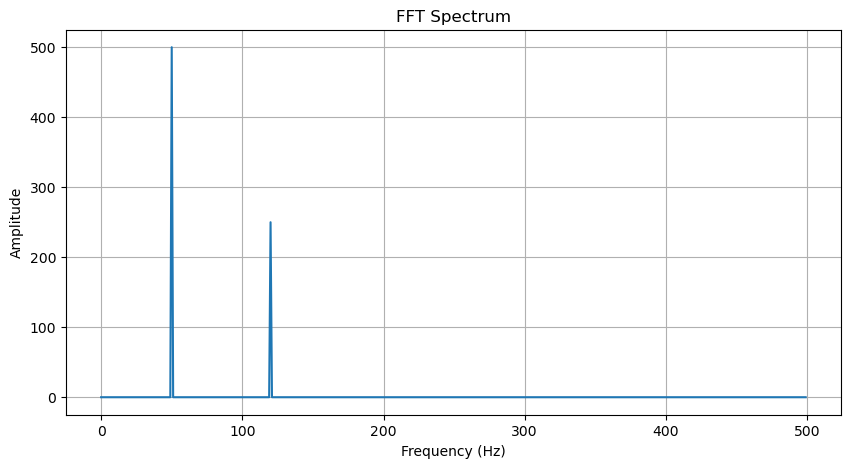

In [2]:
fs = 1000  # Sampling frequency
t = np.linspace(0, 1, fs, endpoint=False)
signal = np.sin(2*np.pi*50*t) + 0.5*np.sin(2*np.pi*120*t)

fft_vals = np.fft.fft(signal)
freqs = np.fft.fftfreq(len(t), 1/fs)

plt.figure(figsize=(10, 5))
plt.plot(freqs[:fs//2], np.abs(fft_vals)[:fs//2])
plt.title('FFT Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid()
plt.show()

## Part 3: Short-Time Fourier Transform (STFT)

STFT gives time-localized frequency information using sliding windows.

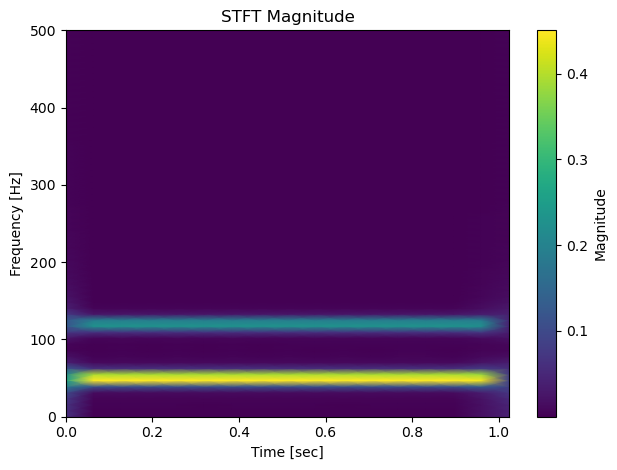

In [3]:
from scipy.signal import stft

f, t, Zxx = stft(signal, fs=fs, nperseg=128)
plt.pcolormesh(t, f, np.abs(Zxx), shading='gouraud')
plt.title('STFT Magnitude')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.colorbar(label='Magnitude')
plt.tight_layout()
plt.show()